# Window and hop modes

This notebook walks through every `window_mode` and `hop_mode` supported by `DSTFT`, on the same synthetic multi-component signal, so you can see what each parameterization buys you before picking one for your own signal.

- `window_mode`: how the analysis window length is allowed to vary —
  `"fixed"` (not learnable), `"constant"` (one learnable scalar), `"time"` (one value per frame), `"frequency"` (one value per frequency bin), `"time-frequency"` (one value per time-frequency bin).
- `hop_mode`: how the frame spacing is allowed to vary — `"fixed"`, `"constant"`, `"time"` (per-frame hop, i.e. non-uniformly spaced frames).

In [1]:
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
print(device, torch.__version__)
torch.manual_seed(1802)

%load_ext autoreload
%autoreload 2
%matplotlib inline

cpu 2.13.0+cu130


## 1. Signal and loss

In [2]:
def entropy_loss(x: torch.Tensor):
    """A simple loss function to encourage spectrogram sparsity."""
    x1 = torch.reshape(x, (x.shape[0], -1))  # B, N
    probs = torch.div(x1.T, x1.sum(dim=-1)).T  # B, N
    entropy = -(
        probs * torch.clamp(torch.log(probs), min=torch.finfo(x.dtype).min)
    ).sum(dim=-1)  # B
    return entropy.mean()

In [3]:
from math import pi


# A signal with a slow tone and a fast tone: no single window length is
# optimal for both at once, which is exactly the case adaptive windows help with.
duration = 1024
sr = 5
t = torch.arange(0, duration, 1 / sr, dtype=dtype, device=device) / float(duration)

slow_tone = torch.cos(2 * pi * 40.0 * t * sr)
fast_tone = torch.cos(2 * pi * 180.0 * t * sr)
# the fast tone only appears in the second half of the signal
mask = (t > 0.5).float()

x = (slow_tone + mask * fast_tone)[None, :]
x += 0.01 * torch.randn_like(x)

print(f"Signal shape: {x.shape}, {x.device}")

Signal shape: torch.Size([1, 5120]), cpu


## 2. `window_mode`: fixed, constant, time, frequency, time-frequency

In [4]:
import matplotlib.pyplot as plt

from dstft import DSTFT


plt.rcParams["figure.dpi"] = 45  # keep saved notebook outputs small

n_fft = 512
win_length = 256
hop_length = 32
epochs = 3_000
lr = 1
patience = 9
factor = 0.1
threshold = 0.5

window_modes = ["fixed", "constant", "time", "frequency", "time-frequency"]
results = {}

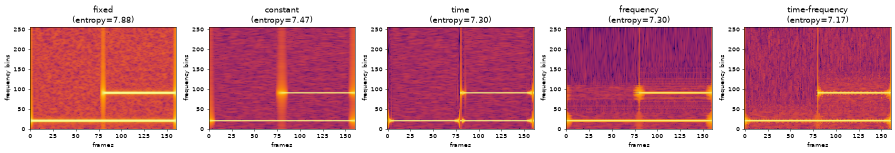

In [5]:
# one shared figure (rather than one figure per mode) to keep this notebook's
# saved size small
fig, axes = plt.subplots(1, len(window_modes), figsize=(4 * len(window_modes), 3.5))

for ax, window_mode in zip(axes, window_modes, strict=True):
    dstft = DSTFT(
        win_length=win_length,
        n_fft=n_fft,
        hop_length=hop_length,
        window_mode=window_mode,
    )
    dstft.initialize(x)

    if window_mode == "fixed":
        spec, _ = dstft(x)
        final_loss = entropy_loss(spec).item()
    else:
        optimizer = torch.optim.Adam(dstft.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=optimizer, mode="min", factor=factor, patience=patience
        )
        for _ in range(epochs):
            optimizer.zero_grad(set_to_none=True)
            spec, _ = dstft(x)
            loss = entropy_loss(spec)
            loss.backward()
            optimizer.step()
            scheduler.step(loss.detach())
            if optimizer.param_groups[0]["lr"] < threshold:
                break
        spec, _ = dstft(x)
        final_loss = entropy_loss(spec).item()

    results[window_mode] = final_loss
    dstft.plot_spec(
        spec,
        ax=ax,
        show=False,
        colorbar=False,
        title=f"{window_mode}\n(entropy={final_loss:.2f})",
    )

fig.tight_layout()
plt.show()

Lower entropy means a sparser, more concentrated spectrogram. Modes that let the window adapt (`"time"`, `"frequency"`, `"time-frequency"`) can resolve both the slow and the fast tone better than a single fixed window, at the cost of more parameters to fit.

In [6]:
for window_mode, loss in results.items():
    print(f"{window_mode:>15s}: entropy = {loss:.4f}")

          fixed: entropy = 7.8753
       constant: entropy = 7.4688
           time: entropy = 7.2983
      frequency: entropy = 7.3009
 time-frequency: entropy = 7.1741


## 3. `hop_mode`: fixed, constant, time

`hop_mode` controls the frame spacing instead of the window length. `"time"` lets each hop be learned independently, i.e. frames can bunch up where the signal changes quickly and spread out where it's stationary.

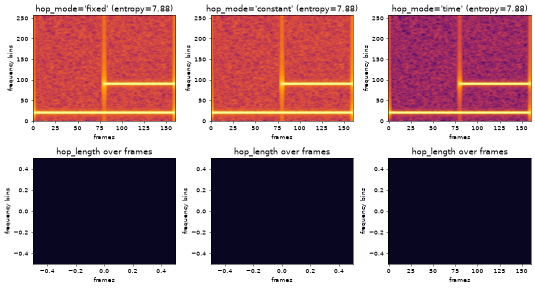

In [7]:
from dstft.visualization import plot_win_lengths


hop_modes = ["fixed", "constant", "time"]
hop_results = {}
fig, axes = plt.subplots(2, len(hop_modes), figsize=(4 * len(hop_modes), 6.5))

for col, hop_mode in enumerate(hop_modes):
    # window_mode="fixed" here so only the hop is varying in this section
    dstft = DSTFT(
        win_length=win_length,
        n_fft=n_fft,
        hop_length=hop_length,
        window_mode="fixed",
        hop_mode=hop_mode,
    )
    dstft.initialize(x)

    if hop_mode == "fixed":
        spec, _ = dstft(x)
        final_loss = entropy_loss(spec).item()
    else:
        optimizer = torch.optim.Adam(dstft.parameters(), lr=lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer=optimizer, mode="min", factor=factor, patience=patience
        )
        for _ in range(epochs):
            optimizer.zero_grad(set_to_none=True)
            spec, _ = dstft(x)
            loss = entropy_loss(spec)
            loss.backward()
            optimizer.step()
            scheduler.step(loss.detach())
            if optimizer.param_groups[0]["lr"] < threshold:
                break
        spec, _ = dstft(x)
        final_loss = entropy_loss(spec).item()

    hop_results[hop_mode] = final_loss
    dstft.plot_spec(
        spec,
        ax=axes[0, col],
        show=False,
        colorbar=False,
        title=f"hop_mode={hop_mode!r} (entropy={final_loss:.2f})",
    )
    plot_win_lengths(
        dstft.hop_length,
        ax=axes[1, col],
        show=False,
        colorbar=False,
        vmin=dstft.hop_length_min,
        vmax=dstft.hop_length_max,
        title="hop_length over frames",
    )

fig.tight_layout()
plt.show()

## 4. Reconstructing the signal

Whatever `window_mode`/`hop_mode` you pick, `DSTFT.inverse` reconstructs the time-domain signal from the (possibly learned) transform — this is what makes `DSTFT` usable as a differentiable front-end inside a larger model, not just an analysis tool.

reconstruction error: 5.8358420318427306e-08


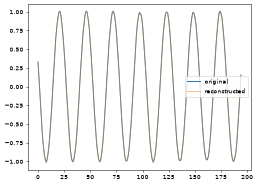

In [8]:
dstft = DSTFT(
    win_length=win_length, n_fft=n_fft, hop_length=hop_length, window_mode="time"
)
dstft.initialize(x)
spec, stft = dstft(x)
x_hat = dstft.inverse(stft)

plt.plot(x[0, 5:200].detach().cpu(), label="original")
plt.plot(x_hat[0, 5:200].detach().cpu(), alpha=0.5, label="reconstructed")
plt.legend()
print("reconstruction error:", (x - x_hat).abs().mean().item())